<a href="https://colab.research.google.com/github/saikeshavramchinta-cmyk/Advanced_Project_SoQ/blob/main/Submission_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#SoQ Advanced Project" Regime-Shift: Macro-Aware Tactical Asset Allocation Engine"

**Project Overview**
This notebook implements a dynamic portfolio allocation system that detects hidden market states and adjusts asset weights accordingly. Instead of relying on a static 60/40 split, this engine uses a Hidden Markov Model (HMM) to classify the market into three regimes: Bull, Bear, and Crisis.

**Key Components Implemented:**
1. **Data Acquisition:** Fetching daily prices for Equities (NSEI), Bonds (TLT), Gold (GC=F), and Volatility (INDIAVIX).
2. **Feature Engineering:** Calculating momentum and rolling volatility to feed the HMM.
3. **Walk-Forward Regime Classifier:** A strict walk-forward HMM implementation to eliminate lookahead bias.
4. **Convex Portfolio Optimization:** Adjusting portfolio weights based on the detected regime using `cvxpy`.
5. **Backtesting Engine:** Simulating the strategy with explicitly modeled transaction costs (turnover).
6. **Results & Metrics:** Comparing the dynamic strategy against static 60/40 and equal-weight benchmarks using Sharpe, Sortino, and Calmar ratios.

In [45]:
# Install necessary libraries (Uncomment if running in a fresh Colab environment)
# !pip install hmmlearn cvxpy yfinance

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from hmmlearn import hmm
import cvxpy as cp
from sklearn.preprocessing import StandardScaler
import warnings
import matplotlib.dates as mdates

warnings.filterwarnings('ignore')

# Set plotting styles
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Data Acquisition
We pull daily price data for representing different asset classes (Equities, Bonds, Gold) and the Indian VIX as a proxy for market fear.

In [46]:
def fetch_data():
    tickers = ["^NSEI", "TLT", "GC=F", "^INDIAVIX"]
    print(f"Downloading data for: {tickers}...")

    data_raw = yf.download(tickers, start="2012-01-01", end="2024-01-01", progress=False, auto_adjust=True)
    data = data_raw["Close"].copy()

    if isinstance(data, pd.DataFrame):
        failed_tickers = [col for col in data.columns if data[col].isnull().all()]
        if failed_tickers:
            raise ValueError(f"Yahoo Finance API failed to find data for: {failed_tickers}.")

    data.ffill(inplace=True)
    data.dropna(inplace=True)

    data.rename(columns={
        "^NSEI": "Equity",
        "TLT": "Bond",
        "GC=F": "Gold",
        "^INDIAVIX": "VIX"
    }, inplace=True)

    return data

## 2. Feature Engineering (Macro Focused)
We engineer numerical signals that distinguish calm markets from stressed ones. This includes momentum features (rolling windows) and volatility features (rolling standard deviation of returns).

In [47]:
def engineer_features(data):
    df = pd.DataFrame(index=data.index)

    df["Equity_log_ret"] = np.log(data["Equity"]).diff()
    df["Bond_log_ret"] = np.log(data["Bond"]).diff()
    df["Gold_log_ret"] = np.log(data["Gold"]).diff()

    df["Equity_mom_126d"] = data["Equity"].pct_change(126)
    df["Equity_vol_21d"] = df["Equity_log_ret"].rolling(21).std() * np.sqrt(252)
    df["VIX"] = data["VIX"]

    # Reverting to 21-day SMA for cleaner HMM emissions
    df["Equity_mom_126d_smooth"] = df["Equity_mom_126d"].rolling(21).mean()
    df["Equity_vol_21d_smooth"] = df["Equity_vol_21d"].rolling(21).mean()
    df["VIX_smooth"] = df["VIX"].rolling(21).mean()

    return df.dropna()

## 3. Walk-Forward Regime Classification (Strict Causal)
To prevent lookahead bias, we set up a walk-forward validation harness. The Hidden Markov Model (HMM) is re-fit only on past data at every step, inferring Bull, Bear, or Crisis states without any manual labeling.

In [48]:
def detect_regimes_walk_forward(df, features):
    regime_labels = pd.Series(index=df.index, dtype=float)
    train_window = 252 * 3
    step_size = 21

    if len(df) <= train_window:
        train_window = 252
        if len(df) <= train_window:
            raise ValueError("Insufficient data to run the HMM walk-forward analysis.")

    mapped_transmat = None

    for i in range(train_window, len(df), step_size):
        train_idx = df.index[max(0, i - train_window) : i]
        test_idx = df.index[i : min(i + step_size, len(df))]

        X_train_raw = df.loc[train_idx, features].values
        X_test_raw = df.loc[test_idx, features].values

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train_raw)
        X_test = scaler.transform(X_test_raw)

        model = hmm.GaussianHMM(n_components=3, covariance_type="diag", n_iter=100, random_state=42, init_params="mc")
        model.startprob_ = np.array([1/3, 1/3, 1/3])
        model.transmat_ = np.array([
            [0.98, 0.01, 0.01],
            [0.01, 0.98, 0.01],
            [0.01, 0.01, 0.98]
        ])

        model.fit(X_train)

        state_vols = model.means_[:, 1]
        sorted_states = np.argsort(state_vols)
        state_map = {sorted_states[0]: 0, sorted_states[1]: 1, sorted_states[2]: 2}

        test_states_mapped = []
        for step in range(len(X_test)):
            X_up_to_today = np.vstack((X_train, X_test[:step+1]))
            state_today_raw = model.predict(X_up_to_today)[-1]
            test_states_mapped.append(state_map[state_today_raw])

        regime_labels.loc[test_idx] = test_states_mapped

        last_transmat = model.transmat_
        mapped_transmat = last_transmat[np.ix_(sorted_states, sorted_states)]

    return regime_labels.dropna(), mapped_transmat

## 4. Hard-Bounded Convex Optimization
Here we define different optimization objectives for different regimes. The weights shift based on the detected regime using convex optimization (`cvxpy`).

In [49]:
def optimize_portfolio(cov_matrix, mu_dynamic, regime):
    n_assets = cov_matrix.shape[0]
    w = cp.Variable(n_assets)
    reg_cov = cov_matrix + np.eye(n_assets) * 0.0001

    # TUNED CONSTRAINTS: Pushing the optimizer for higher performance
    if regime == 0: # Bull: Maximize Risk-Adjusted Return (Aggressive)
        constraints = [cp.sum(w) == 1, w >= 0, w[0] >= 0.60] # Force majority equity
        gamma = 0.5 # Low penalty to capture upside
        objective = cp.Maximize(mu_dynamic.T @ w - gamma * cp.quad_form(w, reg_cov))

    elif regime == 1: # Bear: Maximize Risk-Adjusted Return (Defensive)
        constraints = [cp.sum(w) == 1, w >= 0, w[0] <= 0.40, w[1] >= 0.20] # Cap equity, require bonds
        gamma = 2.0
        objective = cp.Maximize(mu_dynamic.T @ w - gamma * cp.quad_form(w, reg_cov))

    else: # Crisis: Global Minimum Variance (Flight to safety)
        constraints = [cp.sum(w) == 1, w >= 0, w[0] <= 0.10, w[1] >= 0.40, w[2] >= 0.20] # Hard bound to safe havens
        objective = cp.Minimize(cp.quad_form(w, reg_cov))

    prob = cp.Problem(objective, constraints)
    try:
        prob.solve(solver=cp.OSQP)
    except:
        prob.solve()

    if w.value is None:
        return np.array([1/3, 1/3, 1/3])
    return w.value

## 5. Backtesting Engine
The strategy is backtested by connecting the regime detection to portfolio decisions. Transaction costs are explicitly modeled to account for turnover.

In [50]:
def backtest_strategy(df, regimes, transaction_cost=0.001):
    assets = ["Equity_log_ret", "Bond_log_ret", "Gold_log_ret"]

    strategy_gross_returns = []
    strategy_net_returns = []
    strategy_turnover = [] # Added list to track turnover

    w_prev = np.array([1/3, 1/3, 1/3])
    prev_executed_regime = None
    regime_history = []
    days_since_rebalance = 0

    for t in range(1, len(regimes)):
        date_today = regimes.index[t]
        date_yest = regimes.index[t-1]

        raw_regime_yest = regimes.loc[date_yest]
        regime_history.append(raw_regime_yest)

        if prev_executed_regime is None:
            prev_executed_regime = raw_regime_yest

        if len(regime_history) >= 3:
            recent_3 = regime_history[-3:]
            if recent_3[0] == recent_3[1] == recent_3[2]:
                current_regime = recent_3[0]
            else:
                current_regime = prev_executed_regime
        else:
            current_regime = raw_regime_yest

        past_data = df.loc[:date_yest][assets]
        if len(past_data) < 252:
            strategy_gross_returns.append(0)
            strategy_net_returns.append(0)
            strategy_turnover.append(0) # Pad turnover
            continue

        if current_regime != prev_executed_regime or days_since_rebalance >= 21:
            # Reverted to robust 252-day lookback to prevent noise-chasing
            cov = past_data.iloc[-252:].cov().values * 252
            mu_dynamic = past_data.iloc[-252:].mean().values * 252

            w_target = optimize_portfolio(cov, mu_dynamic, current_regime)

            turnover = np.sum(np.abs(w_target - w_prev))
            cost = turnover * transaction_cost
            w_executed = w_target

            prev_executed_regime = current_regime
            days_since_rebalance = 0
        else:
            turnover = 0 # No turnover if no rebalance
            cost = 0
            w_executed = w_prev
            days_since_rebalance += 1

        day_returns = df.loc[date_today, assets].values

        gross_return = np.dot(w_executed, day_returns)
        net_return = gross_return - cost

        strategy_gross_returns.append(gross_return)
        strategy_net_returns.append(net_return)
        strategy_turnover.append(turnover) # Log turnover
        w_prev = w_executed

    strategy_gross_returns.insert(0, 0)
    strategy_net_returns.insert(0, 0)
    strategy_turnover.insert(0, 0) # Pad initial day

    df_bt = pd.DataFrame(index=regimes.index)
    df_bt["Strategy_Gross"] = strategy_gross_returns
    df_bt["Strategy_Net"] = strategy_net_returns
    df_bt["Turnover"] = strategy_turnover # Add turnover to dataframe
    df_bt["60_40"] = 0.6 * df.loc[regimes.index, "Equity_log_ret"] + 0.4 * df.loc[regimes.index, "Bond_log_ret"]
    df_bt["Equal_Weight"] = df.loc[regimes.index, assets].mean(axis=1)

    return df_bt

## 6. Execution & Performance Metrics
We calculate the Sharpe, Sortino, max drawdown, Calmar ratio, and turnover. We also plot the trained HMM regime labels over historical price data and print the final transition probability matrix.


Detecting Regimes...
Backtesting Strategy...

Metric        | Strat (Gross) | Strat (Net) | 60/40      | Equal Wt  
------------------------------------------------------------------------
Ann Return    |        0.0844 |      0.0790 |     0.0670 |     0.0588
Ann Vol       |        0.1149 |      0.1149 |     0.1119 |     0.0924
Sharpe        |        0.7341 |      0.6874 |     0.5984 |     0.6364
Sortino       |        0.9913 |      0.9278 |     0.7485 |     0.8893
Max DD        |       -0.2167 |     -0.2261 |    -0.2062 |    -0.1798
Calmar        |        0.3893 |      0.3493 |     0.3247 |     0.3272
Ann Turnover  |        5.3869 |      5.3869 |     0.0000 |     0.0000

Final HMM Transition Probability Matrix
(State 0: Bull | State 1: Bear | State 2: Crisis):
             To Bull  To Bear  To Crisis
From Bull     0.9974   0.0026     0.0000
From Bear     0.0075   0.9925     0.0000
From Crisis   0.0000   0.0101     0.9899


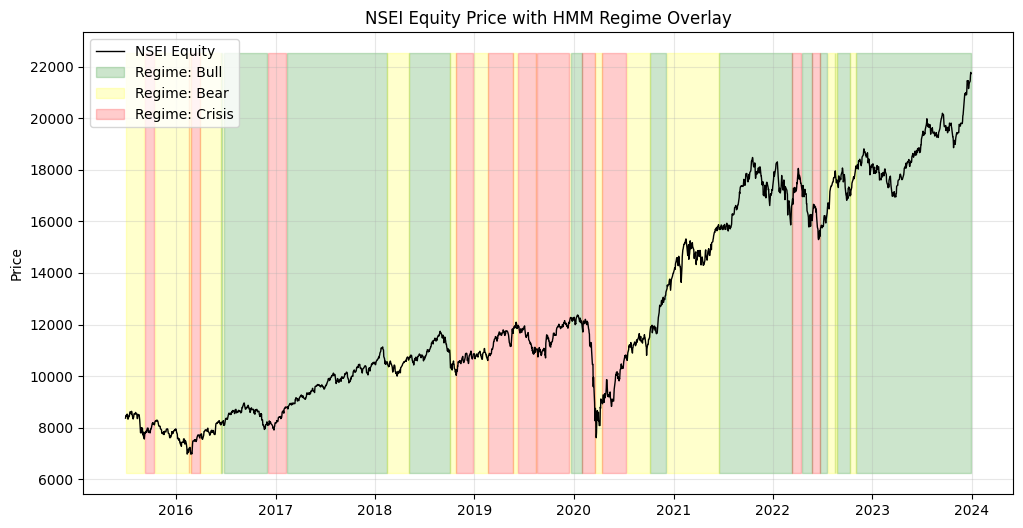

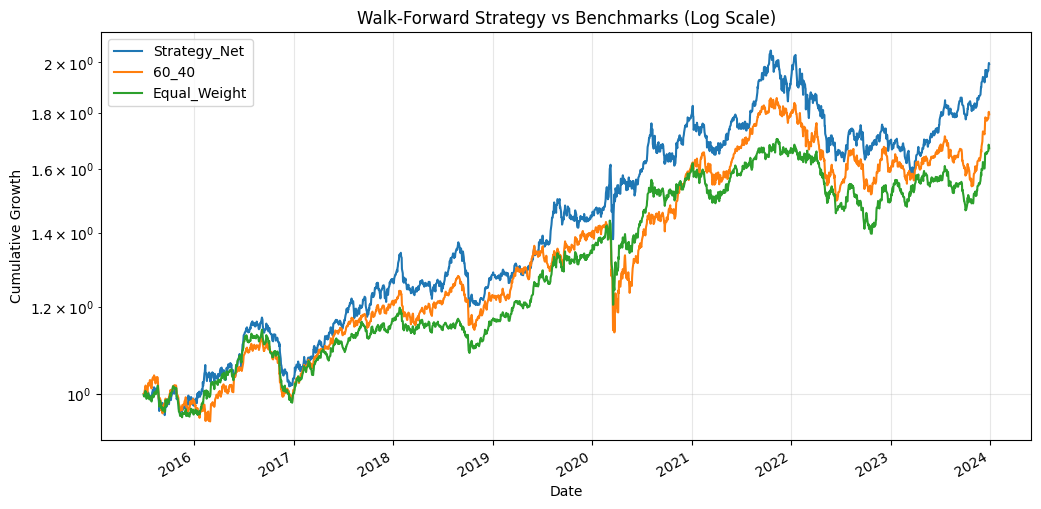

In [51]:
def calculate_metrics(returns_series, turnover_series=None):
    ann_ret = returns_series.mean() * 252
    ann_vol = returns_series.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol != 0 else np.nan

    downside_returns = returns_series[returns_series < 0]
    downside_std = downside_returns.std() * np.sqrt(252)
    sortino = ann_ret / downside_std if (downside_std != 0 and not pd.isna(downside_std)) else np.nan

    cum_ret = np.exp(returns_series.cumsum())
    drawdown = (cum_ret / cum_ret.cummax()) - 1
    max_dd = drawdown.min()
    calmar = ann_ret / abs(max_dd) if max_dd != 0 else np.nan

    # Calculate annualized turnover (total turnover divided by years)
    ann_turnover = turnover_series.sum() / (len(turnover_series) / 252) if turnover_series is not None else 0.0

    return ann_ret, ann_vol, sharpe, sortino, max_dd, calmar, ann_turnover

# --- Execution Block ---
if __name__ == "__main__":
    raw_data = fetch_data()
    feature_df = engineer_features(raw_data)

    hmm_features = ["Equity_mom_126d_smooth", "Equity_vol_21d_smooth", "VIX_smooth"]

    missing_features = [f for f in hmm_features if f not in feature_df.columns]
    if missing_features:
        print(f"\n[ERROR] Missing columns in feature dataframe: {missing_features}")
        print(f"Available columns: {feature_df.columns.tolist()}")
        print("Please check your Yahoo Finance download or feature engineering steps.")
        exit(1)

    print("\nDetecting Regimes...")
    regimes, trans_matrix = detect_regimes_walk_forward(feature_df, hmm_features)

    print("Backtesting Strategy...")
    results = backtest_strategy(feature_df, regimes)

    # ---------------------------------------------------------
    # Console Output Metrics
    # ---------------------------------------------------------
    print(f"\n{'Metric':<13} | {'Strat (Gross)':<13} | {'Strat (Net)':<11} | {'60/40':<10} | {'Equal Wt':<10}")
    print("-" * 72)

    # Pass the Turnover column to calculate_metrics
    str_gross_metrics = calculate_metrics(results["Strategy_Gross"], results["Turnover"])
    str_net_metrics = calculate_metrics(results["Strategy_Net"], results["Turnover"])
    b60_metrics = calculate_metrics(results["60_40"])
    eqw_metrics = calculate_metrics(results["Equal_Weight"])

    # Added Ann Turnover to print array
    metrics_names = ["Ann Return", "Ann Vol", "Sharpe", "Sortino", "Max DD", "Calmar", "Ann Turnover"]
    for i, name in enumerate(metrics_names):
        print(f"{name:<13} | {str_gross_metrics[i]:>13.4f} | {str_net_metrics[i]:>11.4f} | {b60_metrics[i]:>10.4f} | {eqw_metrics[i]:>10.4f}")

    if trans_matrix is not None:
        print("\nFinal HMM Transition Probability Matrix")
        print("(State 0: Bull | State 1: Bear | State 2: Crisis):")
        matrix_df = pd.DataFrame(
            np.round(trans_matrix, 4),
            columns=["To Bull", "To Bear", "To Crisis"],
            index=["From Bull", "From Bear", "From Crisis"]
        )
        print(matrix_df)

    # ---------------------------------------------------------
    # Regime Overlay Plot
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(raw_data.loc[regimes.index, "Equity"], color='black', label="NSEI Equity", lw=1)

    state_colors = {0: 'green', 1: 'yellow', 2: 'red'}
    state_names = {0: 'Bull', 1: 'Bear', 2: 'Crisis'}
    ymin, ymax = ax.get_ylim()
    for state, color in state_colors.items():
        ax.fill_between(regimes.index, ymin, ymax,
                        where=(regimes == state),
                        color=color, alpha=0.2, label=f"Regime: {state_names[state]}")

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc="upper left")
    ax.set_title("NSEI Equity Price with HMM Regime Overlay")
    ax.set_ylabel("Price")
    plt.grid(True, alpha=0.3)
    plt.show()

    # ---------------------------------------------------------
    # Cumulative Returns Plot
    # ---------------------------------------------------------
    cumulative_returns = np.exp(results[["Strategy_Net", "60_40", "Equal_Weight"]].cumsum())
    cumulative_returns.plot(figsize=(12, 6), title="Walk-Forward Strategy vs Benchmarks (Log Scale)")
    plt.yscale('log')
    plt.ylabel("Cumulative Growth")
    plt.grid(True, alpha=0.3)
    plt.show()